# 04 — Train Baseline xG Model
Train a logistic-regression baseline xG model on France/Germany/Italy/Spain and evaluate it on held-out England shots.

This notebook uses the baseline feature table from notebook 03 without adding new features.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.calibration import calibration_curve

from src.config import INTERIM_DIR as DATA_DIR, MODELS_DIR, BASELINE_FEATURES, TARGET_COL, RANDOM_SEED
from src.data_loader import load_parquet
from src.models import build_logistic_xg_pipeline, train_logistic_xg, predict_xg, save_model, load_model
from src.evaluation import metric_summary, build_calibration_table, extract_model_coefficients

## Step 0: Path validation

In [2]:
TRAIN_PATH = DATA_DIR / "wyscout_train_xg_baseline.parquet"
TEST_PATH  = DATA_DIR / "wyscout_test_xg_baseline.parquet"

assert TRAIN_PATH.exists(), "Run 03_engineer_baseline_xg_features.ipynb first"
assert TEST_PATH.exists(),  "Run 03_engineer_baseline_xg_features.ipynb first"
# No MODELS_DIR.mkdir() needed — save_model() calls ensure_dir internally.
print("Paths OK")

Paths OK


## Step 1: Load baseline train/test data

In [ ]:
train = load_parquet(TRAIN_PATH)
test  = load_parquet(TEST_PATH)

FEATURES = BASELINE_FEATURES
TARGET   = TARGET_COL
ID_COLS  = ["league", "matchId", "playerId", "teamId", "eventSec", "matchPeriod"]

assert len(train) > 0, "Empty train set"
assert len(test)  > 0, "Empty test set"
assert set(train["league"].unique()) == {"France", "Germany", "Italy", "Spain"}, "Wrong leagues in train"
assert set(test["league"].unique())  == {"England"}, "Wrong leagues in test"

required_cols = set(FEATURES + [TARGET] + ID_COLS)
assert required_cols.issubset(train.columns), f"Missing train columns: {required_cols - set(train.columns)}"
assert required_cols.issubset(test.columns),  f"Missing test columns: {required_cols - set(test.columns)}"

summary = pd.DataFrame({
    "split":           ["train", "test_epl"],
    "rows":            [len(train), len(test)],
    "goal_rate":       [train[TARGET].mean(), test[TARGET].mean()],
    "penalty_rate":    [train["is_penalty"].mean(), test["is_penalty"].mean()],
    "direct_fk_rate":  [train["is_direct_free_kick"].mean(), test["is_direct_free_kick"].mean()],
})
display(summary)

## Step 2: Final modelling data checks

In [ ]:
for df_name, df in [("train", train), ("test", test)]:
    assert df[FEATURES + [TARGET]].notna().all().all(), f"Nulls in {df_name} model columns"

binary_cols = ["is_penalty", "is_direct_free_kick", "is_left_foot", "is_right_foot", "is_header", "is_goal"]
for df_name, df in [("train", train), ("test", test)]:
    for col in binary_cols:
        assert df[col].isin([0, 1, True, False]).all(), f"{col} not binary in {df_name}"

for df_name, df in [("train", train), ("test", test)]:
    assert not ((df["is_penalty"] == 1) & (df["is_direct_free_kick"] == 1)).any(), \
        f"Mutual exclusivity violated in {df_name}"

for df_name, df in [("train", train), ("test", test)]:
    assert np.isfinite(df["distance_to_goal"]).all(), f"Non-finite distance_to_goal in {df_name}"
    assert np.isfinite(df["shot_angle_rad"]).all(),   f"Non-finite shot_angle_rad in {df_name}"
    assert df["distance_to_goal"].ge(0).all(),        f"Negative distance_to_goal in {df_name}"
    assert df["shot_angle_rad"].between(0, np.pi).all(), f"shot_angle_rad out of range in {df_name}"

for df in [train, test]:
    df["is_penalty"]          = df["is_penalty"].astype("int8")
    df["is_direct_free_kick"] = df["is_direct_free_kick"].astype("int8")
    df["is_left_foot"]        = df["is_left_foot"].astype("int8")
    df["is_right_foot"]       = df["is_right_foot"].astype("int8")
    df["is_header"]           = df["is_header"].astype("int8")
    df["is_goal"]             = df["is_goal"].astype("int8")

print("All data checks passed")
display(train[FEATURES].describe().T)

## Step 3: Build training matrices

In [5]:
X_train = train[FEATURES].copy()
y_train = train[TARGET].copy()
X_test  = test[FEATURES].copy()
y_test  = test[TARGET].copy()

assert X_train.shape[1] == len(FEATURES)
assert X_test.shape[1]  == len(FEATURES)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (34159, 7)
X_test:  (8881, 7)


## Step 4: Define the baseline logistic-regression pipeline

- Logistic regression is the locked baseline model for this notebook.
- L2 regularisation (`C=1.0`) is the stable default — no tuning is performed.
- No class weighting, no calibration wrapper, no model comparison here.

In [6]:
baseline_model = build_logistic_xg_pipeline(random_state=RANDOM_SEED)

## Step 5: Fit the model and generate xG predictions

In [7]:
baseline_model = train_logistic_xg(baseline_model, X_train, y_train)

train_pred = predict_xg(baseline_model, X_train)
test_pred  = predict_xg(baseline_model, X_test)

assert np.isfinite(train_pred).all(), "Non-finite train predictions"
assert np.isfinite(test_pred).all(),  "Non-finite test predictions"
assert ((train_pred >= 0) & (train_pred <= 1)).all(), "Train predictions out of [0,1]"
assert ((test_pred  >= 0) & (test_pred  <= 1)).all(), "Test predictions out of [0,1]"

train_pred_df = train.copy()
test_pred_df  = test.copy()
train_pred_df["xg_pred"] = train_pred
test_pred_df["xg_pred"]  = test_pred

display(test_pred_df[FEATURES + ["is_goal", "xg_pred"]].head())

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,distance_to_goal,shot_angle_rad,is_penalty,is_direct_free_kick,is_left_foot,is_right_foot,is_header,is_goal,xg_pred
0,14.007655,0.467241,0,0,0,1,0,1,0.137206
1,15.808608,0.453557,0,0,1,0,0,0,0.117335
2,4.414703,1.375115,0,0,0,0,1,1,0.421288
3,23.057235,0.274666,0,0,1,0,0,0,0.044315
4,29.563872,0.219665,0,0,0,1,0,0,0.020479


## Step 6: Evaluate discrimination and probability quality

- `log_loss` and `brier_score` are the **primary** xG quality metrics (probability estimation).
- `roc_auc` and `average_precision` are **ranking** diagnostics.
- Accuracy at threshold 0.5 is intentionally excluded — xG is a probability task, not hard classification.

In [ ]:
metrics_df = pd.DataFrame([
    metric_summary(y_train, train_pred, "train"),
    metric_summary(y_test,  test_pred,  "test_epl"),
])

display(metrics_df)

print("Train mean xG vs goal rate:", round(train_pred.mean(), 4), round(y_train.mean(), 4))
print("Test mean xG vs goal rate: ", round(test_pred.mean(),  4), round(y_test.mean(),  4))

## Step 7: EPL calibration analysis

In [ ]:
# Calibration table uses pd.qcut; the plot below uses sklearn's calibration_curve(strategy='quantile') —
# intentionally separate implementations: table for human readability, curve for the plot.
calibration_table = build_calibration_table(y_test, test_pred, n_bins=10)
display(calibration_table)

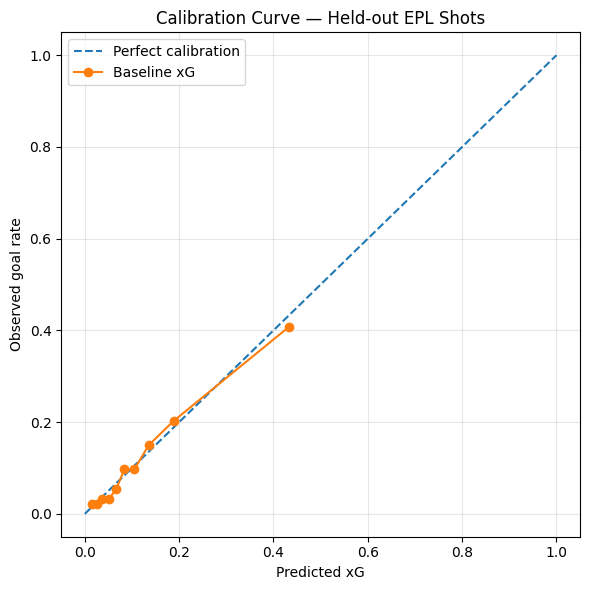

In [10]:
prob_true, prob_pred = calibration_curve(y_test, test_pred, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.plot(prob_pred, prob_true, marker="o", label="Baseline xG")
ax.set_xlabel("Predicted xG")
ax.set_ylabel("Observed goal rate")
ax.set_title("Calibration Curve — Held-out EPL Shots")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(DATA_DIR / "wyscout_xg_baseline_calibration.png", dpi=150)
plt.show()

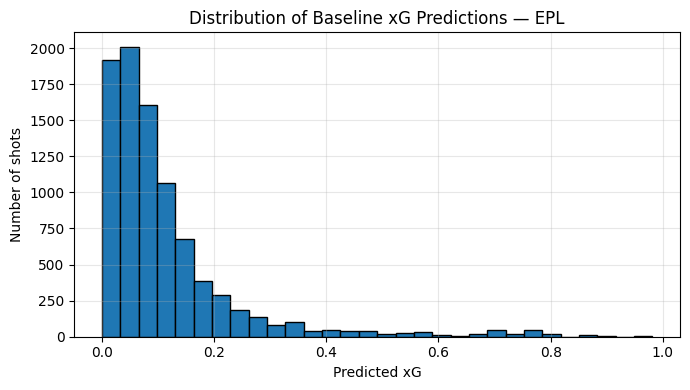

In [11]:
plt.figure(figsize=(7, 4))
plt.hist(test_pred, bins=30, edgecolor="black")
plt.xlabel("Predicted xG")
plt.ylabel("Number of shots")
plt.title("Distribution of Baseline xG Predictions — EPL")
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(DATA_DIR / "wyscout_xg_baseline_score_distribution.png", dpi=150)
plt.show()

## Step 8: Interpret the fitted model

In [12]:
coef_df = extract_model_coefficients(baseline_model, FEATURES)
display(coef_df)

intercept = baseline_model.named_steps["logreg"].intercept_[0]
print("Intercept:", round(intercept, 4))

,feature,coefficient,odds_ratio
1,shot_angle_rad,0.422643,1.525989
2,is_penalty,0.260401,1.297451
3,is_direct_free_kick,0.195794,1.216277
4,is_left_foot,0.111346,1.117782
5,is_right_foot,0.103132,1.108638
6,is_header,-0.289202,0.748861
0,distance_to_goal,-0.890907,0.410283


Intercept: -2.5251


**Coefficient interpretation:**
- Coefficients are on the **scaled** feature scale (post-`StandardScaler`): each reflects a one-standard-deviation change in the feature, not a one-metre or one-radian change.
- `distance_to_goal` should have a large **negative** coefficient — shots further from goal in SD terms are much less likely to score.
- `shot_angle_rad` should be **positive** — a wider angle to goal increases xG.
- `is_penalty` should be **strongly positive** — in-game awarded penalties convert at a much higher rate than open-play shots.
- `is_direct_free_kick` is likely **negative** relative to open-play shots — direct free kicks from comparable distances convert less often due to the defensive wall — but this is an interpretive expectation, not an assertion.
- `is_header` may be negative relative to footed shots after controlling for geometry (headers tend to be closer but from more difficult positions).
- The intercept represents log-odds at the **mean** feature values after scaling, not at all-zero raw inputs.

## Step 9: Save predictions, metrics, and model artifact

In [13]:
train_pred_df.to_parquet(DATA_DIR / "wyscout_train_xg_baseline_predictions.parquet", index=False)
test_pred_df.to_parquet(DATA_DIR  / "wyscout_test_xg_baseline_predictions.parquet",  index=False)

print(f"Saved {len(train_pred_df):,} train predictions")
print(f"Saved {len(test_pred_df):,} EPL test predictions")

Saved 34,159 train predictions
Saved 8,881 EPL test predictions


In [14]:
metrics_records = metrics_df.to_dict(orient="records")
with open(DATA_DIR / "wyscout_xg_baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_records, f, indent=2)

metrics_df.to_csv(DATA_DIR / "wyscout_xg_baseline_metrics.csv", index=False)
calibration_table.to_csv(DATA_DIR / "wyscout_xg_baseline_calibration_table.csv", index=False)

print("Saved metrics and calibration table")

Saved metrics and calibration table


In [15]:
save_model(baseline_model, MODELS_DIR / "wyscout_xg_baseline_logreg.joblib")
print("Saved model artifact:", MODELS_DIR / "wyscout_xg_baseline_logreg.joblib")

Saved model artifact: C:\Users\User\.vscode\Final Year Project\Code\models\wyscout_xg_baseline_logreg.joblib


## Step 10: Reload verification

In [16]:
train_check   = pd.read_parquet(DATA_DIR / "wyscout_train_xg_baseline_predictions.parquet")
test_check    = pd.read_parquet(DATA_DIR  / "wyscout_test_xg_baseline_predictions.parquet")
metrics_check = pd.read_csv(DATA_DIR / "wyscout_xg_baseline_metrics.csv")

assert len(train_check) == len(train_pred_df), "Train prediction row count mismatch"
assert len(test_check)  == len(test_pred_df),  "Test prediction row count mismatch"
assert "xg_pred" in train_check.columns, "Missing xg_pred in train predictions"
assert "xg_pred" in test_check.columns,  "Missing xg_pred in test predictions"
assert train_check["xg_pred"].notna().all(),        "Null xg_pred in train predictions"
assert test_check["xg_pred"].notna().all(),         "Null xg_pred in test predictions"
assert train_check["xg_pred"].between(0, 1).all(),  "Train xg_pred out of [0,1]"
assert test_check["xg_pred"].between(0, 1).all(),   "Test xg_pred out of [0,1]"

assert {"split", "roc_auc", "average_precision", "log_loss", "brier_score"}.issubset(metrics_check.columns)
assert set(metrics_check["split"]) == {"train", "test_epl"}

loaded_model     = load_model(MODELS_DIR / "wyscout_xg_baseline_logreg.joblib")
loaded_test_pred = predict_xg(loaded_model, test[FEATURES])
assert np.allclose(loaded_test_pred, test_pred, rtol=1e-5, atol=1e-9), \
    "Reloaded model predictions differ"

print("Reload verification passed")
print(test_check[["is_goal", "xg_pred"]].head())

Reload verification passed
   is_goal   xg_pred
0        1  0.137206
1        0  0.117335
2        1  0.421288
3        0  0.044315
4        0  0.020479
